In [28]:
import pandas as pd

df_text = pd.read_csv(
    "/content/mtsamples.csv",
    header=None,
    engine="python"
)

print(df_text.shape)
print(df_text.head())

(1205, 31)
                                                  0   \
0  fold extending into the anterior arytenoid are...   
1                                               3795   
2                                               3796   
3                                               3797   
4                                               3798   

                                                  1   \
0   a decision was then made to go ahead and perf...   
1   Chief complaint of chest pain, previously dia...   
2   Return visit to the endocrine clinic for foll...   
3   Thyroid mass diagnosed as papillary carcinoma...   
4   The patient with left completion hemithyroide...   

                             2   \
0   and 1% lidocaine with 1:100   
1                 Endocrinology   
2                 Endocrinology   
3                 Endocrinology   
4                 Endocrinology   

                                                  3   \
0  000 epinephrine was injected.  A shoulder rol

In [29]:
print(df_text.iloc[0].tolist())

['fold extending into the anterior arytenoid area and extending about 1 cm below into the subglottis.  Subsequently', ' a decision was then made to go ahead and perform the surgical intervention.  A hemi-apron incision was employed', ' and 1% lidocaine with 1:100', '000 epinephrine was injected.  A shoulder roll was applied after the patient was prepped and draped in a sterile fashion.  Subsequently', ' a hemi-apron incision was performed.  Subplatysmal flaps were raised at the hyoid bone into the clavicle.  Attention was then turned to the right side', ' where a level 2', np.float64(3.0), ' 4 neck dissection was performed.  Submandibular fascia was appreciated inferiorly along the submandibular gland', ' this was incised allowing for identification of the digastric muscle.  Digastric tunnel was performed posteriorly to the level of the sternocleidomastoid muscle.  The fascia along the sternocleidomastoid muscle was then dissected along the anterior aspect until the cranial nerve XI wa

In [30]:
print(df_text.shape)
print(df_text.iloc[0].tolist())

(1205, 31)
['fold extending into the anterior arytenoid area and extending about 1 cm below into the subglottis.  Subsequently', ' a decision was then made to go ahead and perform the surgical intervention.  A hemi-apron incision was employed', ' and 1% lidocaine with 1:100', '000 epinephrine was injected.  A shoulder roll was applied after the patient was prepped and draped in a sterile fashion.  Subsequently', ' a hemi-apron incision was performed.  Subplatysmal flaps were raised at the hyoid bone into the clavicle.  Attention was then turned to the right side', ' where a level 2', np.float64(3.0), ' 4 neck dissection was performed.  Submandibular fascia was appreciated inferiorly along the submandibular gland', ' this was incised allowing for identification of the digastric muscle.  Digastric tunnel was performed posteriorly to the level of the sternocleidomastoid muscle.  The fascia along the sternocleidomastoid muscle was then dissected along the anterior aspect until the cranial 

In [31]:
raw = pd.read_csv("/content/mtsamples.csv", header=None, engine="python")
text_data = raw.iloc[:, :-1].fillna("").astype(str)

df_text = pd.DataFrame({
    "transcription": text_data.apply(
        lambda row: " ".join(x for x in row if x != "nan"),
        axis=1
    ),
    "keywords": raw.iloc[:, -1].fillna("")
})

print("Shape:", df_text.shape)
df_text.head()

Shape: (1205, 2)


,transcription,keywords
0,fold extending into the anterior arytenoid are...,"endocrinology, laryngectomy, neck dissection, ..."
1,"3795 Chief complaint of chest pain, previousl...",
2,3796 Return visit to the endocrine clinic for...,
3,3797 Thyroid mass diagnosed as papillary carc...,
4,3798 The patient with left completion hemithy...,


In [32]:
df_text["clean_text"] = (
    df_text["transcription"]
    .str.lower()
    .str.replace(r'\b[\w.-]+@[\w.-]+\.\w+\b', ' [EMAIL] ', regex=True)
    .str.replace(r'\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b', ' [PHONE] ', regex=True)
    .str.replace(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', ' [DATE] ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [33]:
df_text["word_count"] = df_text["clean_text"].str.split().str.len()

print("Documents:", len(df_text))
print("Average words:", df_text["word_count"].mean())
print("Maximum words:", df_text["word_count"].max())

Documents: 1205
Average words: 550.301244813278
Maximum words: 3046


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_text = tfidf.fit_transform(df_text["clean_text"])

print("Model-ready shape:", X_text.shape)

Model-ready shape: (1205, 1000)


In [35]:
words = tfidf.get_feature_names_out()
scores = X_text.mean(axis=0).A1

top_words = pd.DataFrame({
    "word": words,
    "score": scores
}).sort_values("score", ascending=False)

print(top_words.head(20))

          word     score
666    patient  0.096725
432    history  0.084093
505       left  0.051077
655       pain  0.051042
792      right  0.049701
622     normal  0.046009
561         mg  0.041888
183      chest  0.033255
285  discharge  0.032377
102     artery  0.030990
729  pulmonary  0.030300
289    disease  0.029255
229   coronary  0.027653
219    consult  0.026818
137      blood  0.026789
419      heart  0.026694
663       past  0.026615
244      daily  0.026128
260     denies  0.025448
718  procedure  0.024303


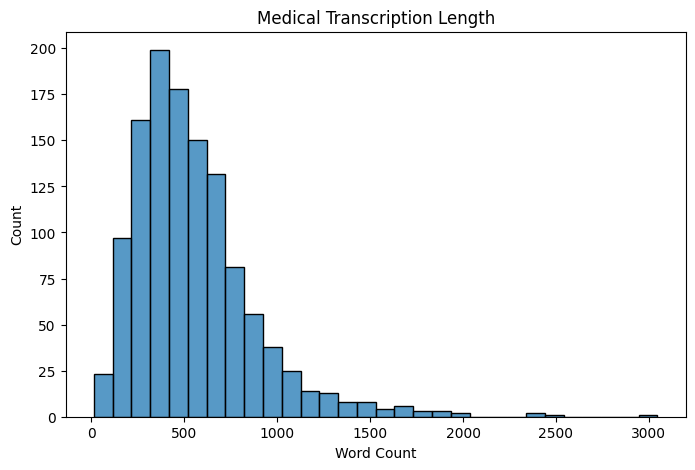

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df_text["word_count"], bins=30)
plt.title("Medical Transcription Length")
plt.xlabel("Word Count")
plt.show()

In [37]:
df_text.to_csv("mtsamples_cleaned.csv", index=False)

print("PART B COMPLETE")

PART B COMPLETE
